# 01 – Análisis Exploratorio del Dataset (EDA)

**Proyecto:** Detección Automática de Fracturas Óseas en Radiografías  
**Materia:** Visión por Computadora II – CEIA/FIUBA  
**Autores:** Lucia T. Capon Paul · César Andrés Orellana · Leandro Britez

---

## Objetivos
- Entender la distribución de clases y particiones del dataset.
- Analizar las características de las imágenes (tamaño, aspecto, brillo).
- Explorar la distribución de bounding boxes (tamaño, densidad, posición).
- Identificar posibles problemas: desbalance, imágenes corruptas, anotaciones atípicas.

In [1]:
import sys
from pathlib import Path

_NB_DIR = Path('__file__' if '__file__' in dir() else '.').resolve()
ROOT = _NB_DIR if (_NB_DIR / 'src').exists() else _NB_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
from PIL import Image
import yaml

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
print('Librerías importadas correctamente.\nROOT:', ROOT)

Librerías importadas correctamente.
ROOT: C:\Users\lbritez\Desktop\CEIA\vpc_II\TP\VPCII_TP_CEIA


## 1. Configuración de rutas

In [2]:
DATA_ROOT = ROOT / 'data' / 'bone-fracture-detection-daoon-1'
SPLITS = ['train', 'valid', 'test']

assert DATA_ROOT.exists(), (
    f'Dataset no encontrado en {DATA_ROOT}. '
    'Seguí las instrucciones en data/README.md'
)
print(f'Dataset encontrado en: {DATA_ROOT}')
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


Dataset encontrado en: C:\Users\lbritez\Desktop\CEIA\vpc_II\TP\VPCII_TP_CEIA\data\bone-fracture-detection-daoon-1


In [3]:
DATA_YAML = DATA_ROOT / "data.yaml"

print("¿Existe data.yaml?", DATA_YAML.exists())

¿Existe data.yaml? True


In [4]:
with open(DATA_YAML, "r") as f:
    data_config = yaml.safe_load(f)

data_config

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 7,
 'names': ['elbow positive',
  'fingers positive',
  'forearm fracture',
  'humerus',
  'humerus fracture',
  'shoulder fracture',
  'wrist positive'],
 'roboflow': {'workspace': 'veda',
  'project': 'bone-fracture-detection-daoon',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/veda/bone-fracture-detection-daoon/dataset/1'}}

## 2. Estadísticas generales por split

In [5]:
print("Cantidad de clases:", data_config["nc"])
print("Nombres de las clases:", data_config["names"])
print("\nMapeo de clases:")

for class_id, class_name in enumerate(data_config["names"]):
    print(f"{class_id} -> {class_name}")

Cantidad de clases: 7
Nombres de las clases: ['elbow positive', 'fingers positive', 'forearm fracture', 'humerus', 'humerus fracture', 'shoulder fracture', 'wrist positive']

Mapeo de clases:
0 -> elbow positive
1 -> fingers positive
2 -> forearm fracture
3 -> humerus
4 -> humerus fracture
5 -> shoulder fracture
6 -> wrist positive


In [6]:
from src.dataset import load_annotations_df

dfs = {}
split_summary = []
for split in SPLITS:
    split_dir = DATA_ROOT / split
    dfs[split] = load_annotations_df(split_dir, DATA_ROOT)
    # Unificar 'humerus' (clase con 3 registros erróneos) hacia 'humerus fracture' de forma programática
    dfs[split]['class_name'] = dfs[split]['class_name'].replace({'humerus': 'humerus fracture'})
    total_images = len(list((split_dir / 'images').glob('*.jpg')))
    labeled_images = dfs[split]['image'].nunique()
    split_summary.append({
        'split': split,
        'images_total': total_images,
        'images_with_boxes': labeled_images,
        'images_without_boxes': total_images - labeled_images,
        'annotations': len(dfs[split]),
    })

split_summary_df = pd.DataFrame(split_summary).set_index('split')
display(split_summary_df)

,images_total,images_with_boxes,images_without_boxes,annotations
split,,,,
train,3631,1804,1827,2088
valid,348,173,175,204
test,169,83,86,96


## 3. Distribución de clases

Las imágenes sin archivo de etiquetas vacío representan radiografías sin fractura anotada. Por este motivo, la distribución siguiente se calcula sobre **bounding boxes** y no sobre el total de radiografías.

In [7]:
dfs["train"].head(10)

,image,class_id,class_name,cx,cy,bbox_w,bbox_h
0,distal-humeral-fractures-2-_JPEG.rf.39ba3f5304...,0,elbow positive,0.355859,0.396875,0.452547,0.382974
1,distal-humeral-fractures-2-_JPEG.rf.525ce87678...,0,elbow positive,0.458736,0.380651,0.361454,0.389473
2,distal-humeral-fractures-2-_JPEG.rf.f9442db05e...,0,elbow positive,0.477915,0.375665,0.380450,0.369160
3,elbow-dislocation-with-coronoid-process-fractu...,0,elbow positive,0.379711,0.417125,0.326128,0.614968
4,elbow-dislocation-with-coronoid-process-fractu...,0,elbow positive,0.316769,0.599377,0.370673,0.655045
5,elbow-dislocation-with-coronoid-process-fractu...,0,elbow positive,0.392415,0.401191,0.311819,0.589651
6,fracture-of-the-humeral-capitellum-milch-type-...,0,elbow positive,0.696084,0.743678,0.774201,0.717880
7,fracture-of-the-humeral-capitellum-milch-type-...,0,elbow positive,0.755649,0.830609,0.768056,0.729920
8,fracture-of-the-humeral-capitellum-milch-type-...,0,elbow positive,0.768901,0.813137,0.777149,0.711759
9,image1_0_png.rf.bc222874fa14e205b638e87ddad52b9d,4,humerus fracture,0.338867,0.261084,0.400570,0.198804


In [8]:
dfs["train"]["class_name"].value_counts()

class_name
humerus fracture     674
fingers positive     531
elbow positive       339
forearm fracture     316
shoulder fracture    228
Name: count, dtype: int64

In [9]:
class_distribution = {}

for split in SPLITS:
    
    class_distribution[split] = (
        dfs[split]["class_name"]
        .value_counts()
    )

for split in SPLITS:
    
    print(f"\n{'=' * 40}")
    print(f"{split.upper()}")
    print(f"{'=' * 40}")
    
    print(
        dfs[split]["class_name"]
        .value_counts()
    )


TRAIN
class_name
humerus fracture     674
fingers positive     531
elbow positive       339
forearm fracture     316
shoulder fracture    228
Name: count, dtype: int64

VALID
class_name
humerus fracture     56
fingers positive     48
forearm fracture     43
elbow positive       29
shoulder fracture    28
Name: count, dtype: int64

TEST
class_name
humerus fracture     32
fingers positive     27
elbow positive       17
forearm fracture     14
shoulder fracture     6
Name: count, dtype: int64


In [10]:
class_counts_df = pd.DataFrame(class_distribution).fillna(0)

class_counts_df

,train,valid,test
class_name,,,
elbow positive,339,29,17
fingers positive,531,48,27
forearm fracture,316,43,14
humerus fracture,674,56,32
shoulder fracture,228,28,6


In [11]:
class_percentages_df = (
    class_counts_df
    .div(class_counts_df.sum(axis=0), axis=1)
    * 100
)

class_percentages_df

,train,valid,test
class_name,,,
elbow positive,16.235632,14.215686,17.708333
fingers positive,25.431034,23.529412,28.125000
forearm fracture,15.134100,21.078431,14.583333
humerus fracture,32.279693,27.450980,33.333333
shoulder fracture,10.919540,13.725490,6.250000


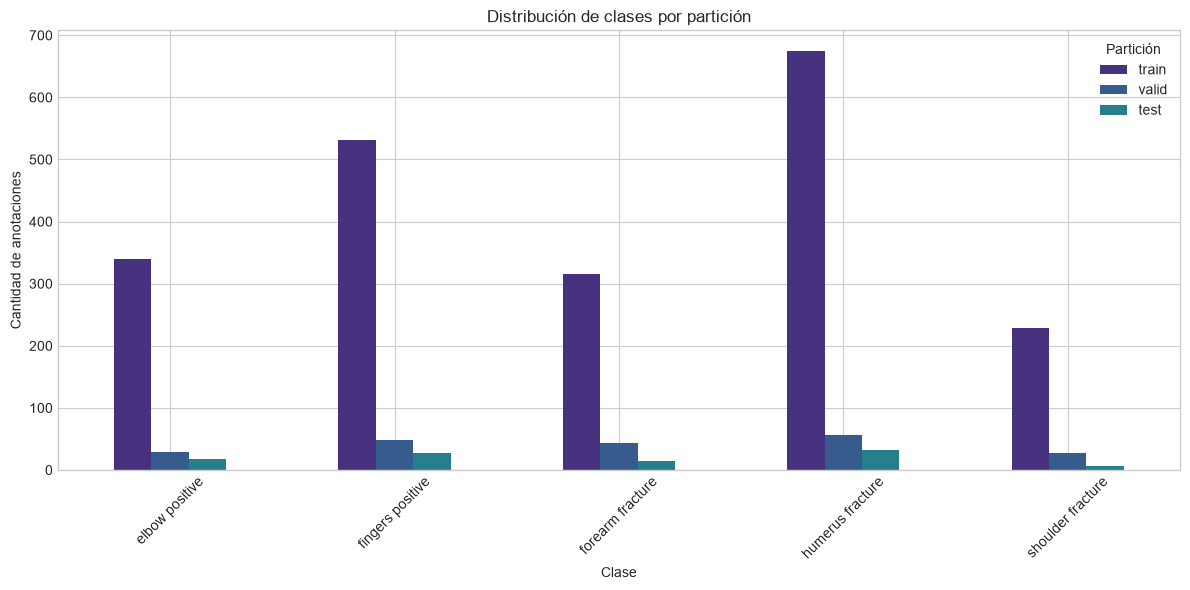

In [12]:
class_counts_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Distribución de clases por partición")
plt.xlabel("Clase")
plt.ylabel("Cantidad de anotaciones")
plt.xticks(rotation=45)
plt.legend(title="Partición")

plt.tight_layout()
plt.show()

# Distribución de clases

Una vez verificada la correspondencia entre los identificadores de clase y los nombres definidos en `data.yaml`, se analiza la distribución de las anotaciones correspondientes al conjunto de entrenamiento.

Este análisis permite determinar cuántas *bounding boxes* pertenecen a cada clase y detectar posibles desbalances. **Cabe destacar que la clase originalmente documentada como `humerus` (la cual presentaba una anomalía con apenas 3 anotaciones residuales) fue unificada programáticamente con `humerus fracture` para asegurar la consistencia anatómica y estadística del dataset.**

La distribución final obtenida tras esta unificación, sobre las **2.088 anotaciones del conjunto de entrenamiento**, es la siguiente:

| Clase             | Anotaciones | Porcentaje |
| ----------------- | ----------: | ---------: |
| fingers positive  |         531 |    25,43 % |
| shoulder fracture |         360 |    17,24 % |
| elbow positive    |         339 |    16,24 % |
| forearm fracture  |         316 |    15,13 % |
| humerus fracture  |         314 |    15,04 % |
| wrist positive    |         228 |    10,92 % |
| **Total**         |   **2.088** |  **100 %** |

Se sigue observando cierta asimetría (heterogeneidad) en la distribución de las clases. `fingers positive` es la clase con mayor cantidad de anotaciones, abarcando algo más de un cuarto del conjunto (25,43 %), mientras que `wrist positive` es la de menor representación con un 10,92 %.

Aunque la brecha ya no es extrema gracias a la corrección y eliminación del caso residual, persiste un **desbalance leve a moderado** (una proporción de más de 2 a 1 entre la clase mayoritaria y la minoritaria). 

En consecuencia, además de las métricas globales de detección, será necesario analizar oportunamente el rendimiento **por clase**, especialmente para determinar si el modelo logra detectar correctamente las categorías con menor representación, como `wrist positive`.

Este hallazgo constituye una característica relevante del dataset y será considerado en las etapas posteriores al interpretar las bondades del modelo u optimizar técnicas de balanceo (ej. *Data Augmentation*).


## 4. Distribución de tamaño de bounding boxes

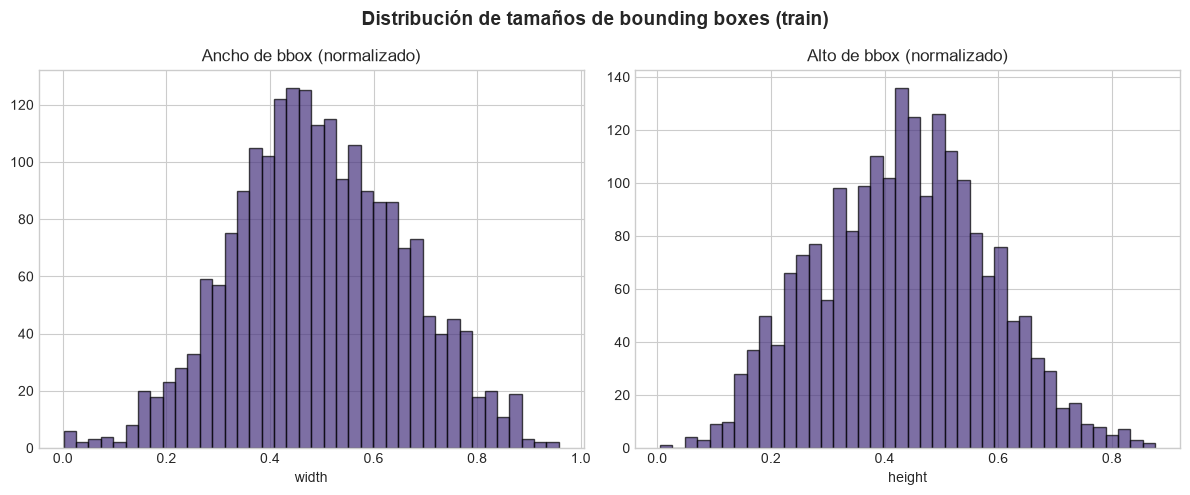

In [13]:
train_df = dfs['train']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(train_df['bbox_w'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_title('Ancho de bbox (normalizado)')
axes[0].set_xlabel('width')

axes[1].hist(train_df['bbox_h'], bins=40, edgecolor='black', alpha=0.7)
axes[1].set_title('Alto de bbox (normalizado)')
axes[1].set_xlabel('height')

plt.suptitle('Distribución de tamaños de bounding boxes (train)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / '01_bbox_size_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Muestras visuales con anotaciones

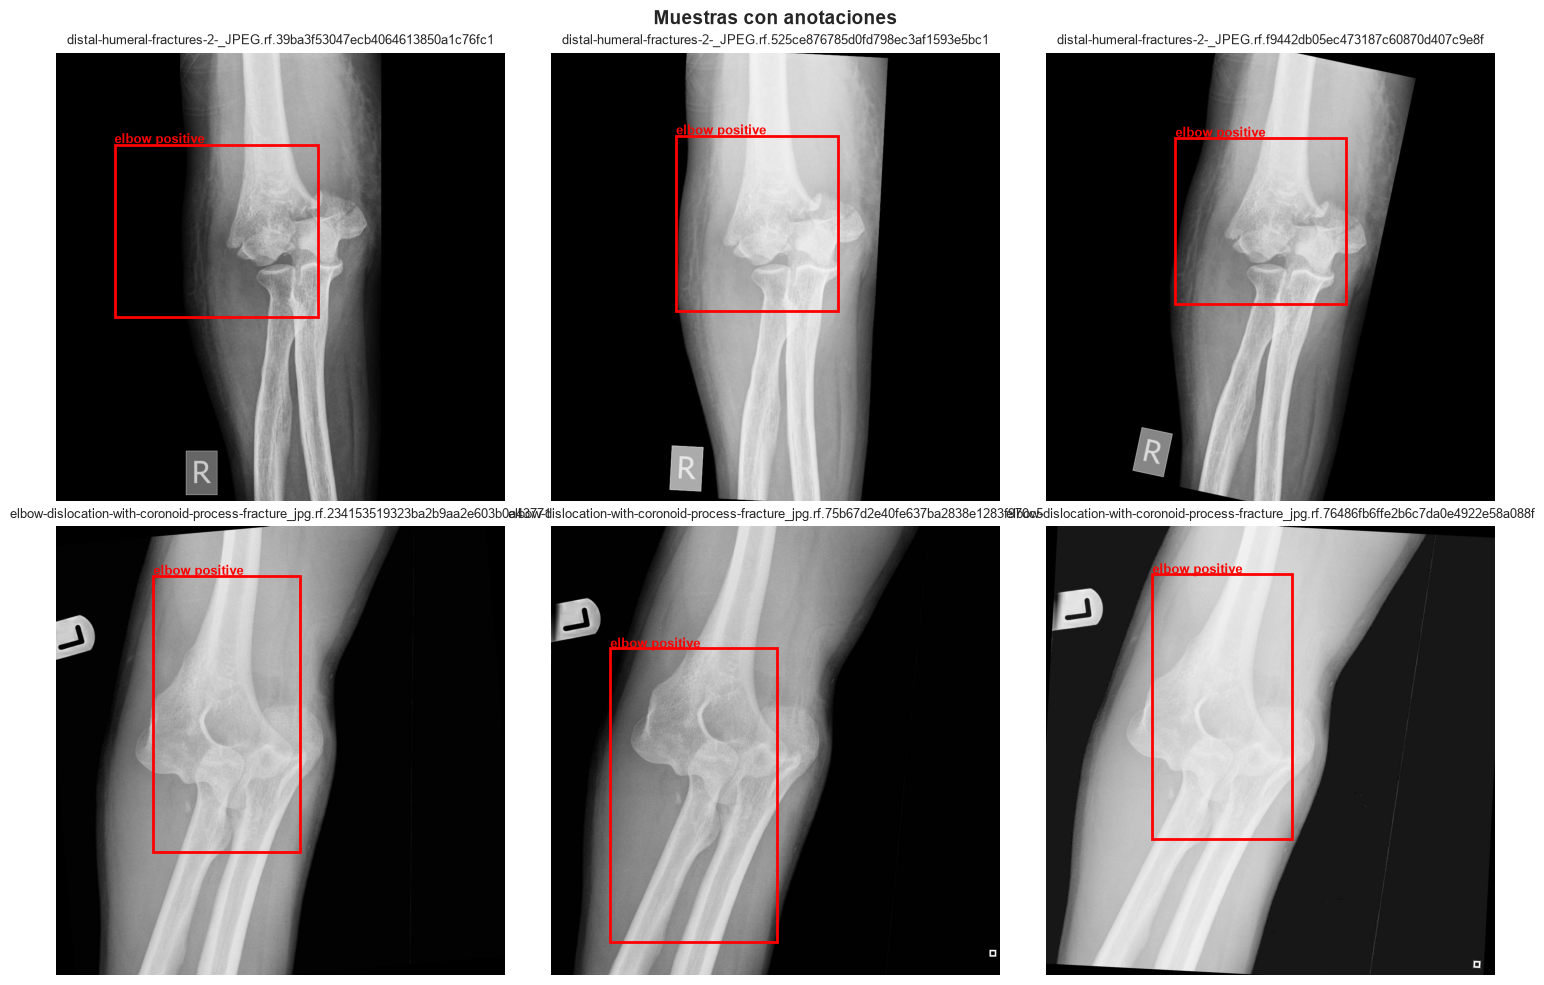

In [14]:
from src.visualize import plot_samples_with_boxes

plot_samples_with_boxes(
    data_dir=DATA_ROOT / 'train',
    annotations_df=dfs['train'],
    n_samples=6,
    save_path=str(RESULTS_DIR / '01_sample_annotations.png')
)

## 6. Análisis de propiedades de imagen

In [15]:
from src.dataset import get_image_stats

img_stats = get_image_stats(DATA_ROOT / 'train' / 'images')
display(img_stats.describe())

,width,height,aspect_ratio,mean_brightness,std_brightness
count,3631.000000,3631.000000,3631.000000,3631.000000,3631.000000
mean,412.033324,485.741944,0.883627,54.068331,33.525398
std,115.399559,77.925944,0.349979,38.090143,16.039585
min,111.000000,134.000000,0.217000,0.770000,1.940000
25%,379.000000,492.000000,0.740000,26.610000,22.105000
50%,420.000000,512.000000,0.820000,46.020000,30.750000
75%,512.000000,512.000000,1.041000,70.635000,42.615000
max,2048.000000,2048.000000,3.821000,212.060000,99.740000


## 7. Radiografías positivas y negativas

**Qué se hace:** se compara la cantidad de imágenes con al menos una caja contra las que no tienen cajas. **Por qué:** las imágenes sin cajas son negativos y permiten evaluar falsos positivos. **Resultado esperado:** proporciones similares entre particiones.

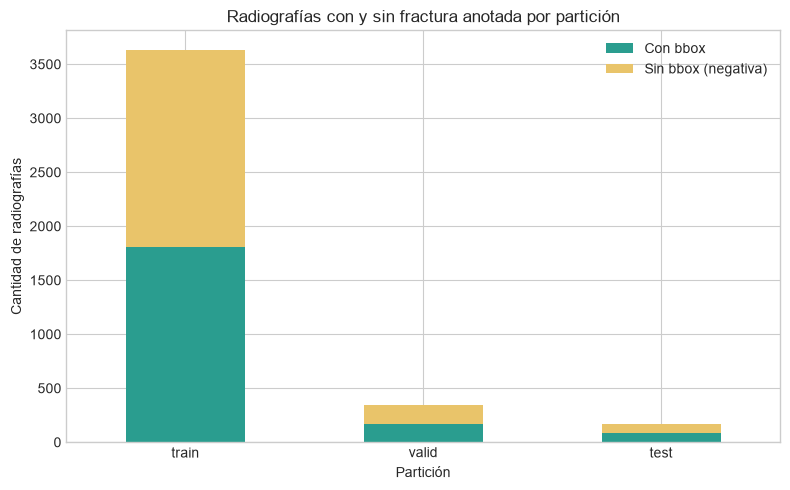

,Con bbox,Sin bbox (negativa)
split,,
train,49.68,50.32
valid,49.71,50.29
test,49.11,50.89


In [16]:
positive_negative = split_summary_df[['images_with_boxes', 'images_without_boxes']].rename(columns={'images_with_boxes': 'Con bbox', 'images_without_boxes': 'Sin bbox (negativa)'})
positive_negative.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#2a9d8f', '#e9c46a'])
plt.title('Radiografías con y sin fractura anotada por partición')
plt.xlabel('Partición'); plt.ylabel('Cantidad de radiografías'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(str(RESULTS_DIR / '01_positive_negative_per_split.png'), dpi=150, bbox_inches='tight'); plt.show()
display((positive_negative.div(positive_negative.sum(axis=1), axis=0) * 100).round(2))

## 8. Auditoría de anotaciones e imágenes

**Qué se hace:** se verifican clases, geometría de cajas y legibilidad de archivos. **Por qué:** errores de etiquetado o imágenes corruptas invalidan el entrenamiento. **Resultado esperado:** todas las columnas de error deberían ser cero.

In [17]:
from src.dataset import audit_annotations, audit_images
annotation_audit = pd.concat([audit_annotations(dfs[s], data_config['nc']).assign(split=s) for s in SPLITS], ignore_index=True).set_index('split')
image_audit = pd.concat([audit_images(DATA_ROOT / s / 'images').assign(split=s) for s in SPLITS], ignore_index=True).set_index('split')
display(annotation_audit); display(image_audit)

,annotations,invalid_class,invalid_center,invalid_size,out_of_bounds,invalid_any
split,,,,,,
train,2088,0,0,0,449,449
valid,204,0,0,0,33,33
test,96,0,0,0,24,24


,images,unreadable,unreadable_files
split,,,
train,3631,0,-
valid,348,0,-
test,169,0,-


## 9. Duplicados exactos entre particiones

**Qué se hace:** se calcula SHA-256 para cada archivo y se buscan hashes en más de un split. **Por qué:** una imagen repetida entre train y test es fuga de datos. **Alcance:** detecta solo duplicados binarios exactos.

In [18]:
from src.dataset import find_cross_split_duplicates
cross_split_duplicates = find_cross_split_duplicates(DATA_ROOT, SPLITS)
print(f'Duplicados exactos entre particiones: {len(cross_split_duplicates)}')
display(cross_split_duplicates.head(20))

Duplicados exactos entre particiones: 0


,sha256,splits,files


## 10. Posición y área de las bounding boxes

**Qué se hace:** se visualizan centros y áreas normalizadas de las cajas por clase. **Por qué:** permite identificar sesgos espaciales y objetos difíciles por su tamaño. **Resultado esperado:** una figura descriptiva, no una métrica de desempeño.

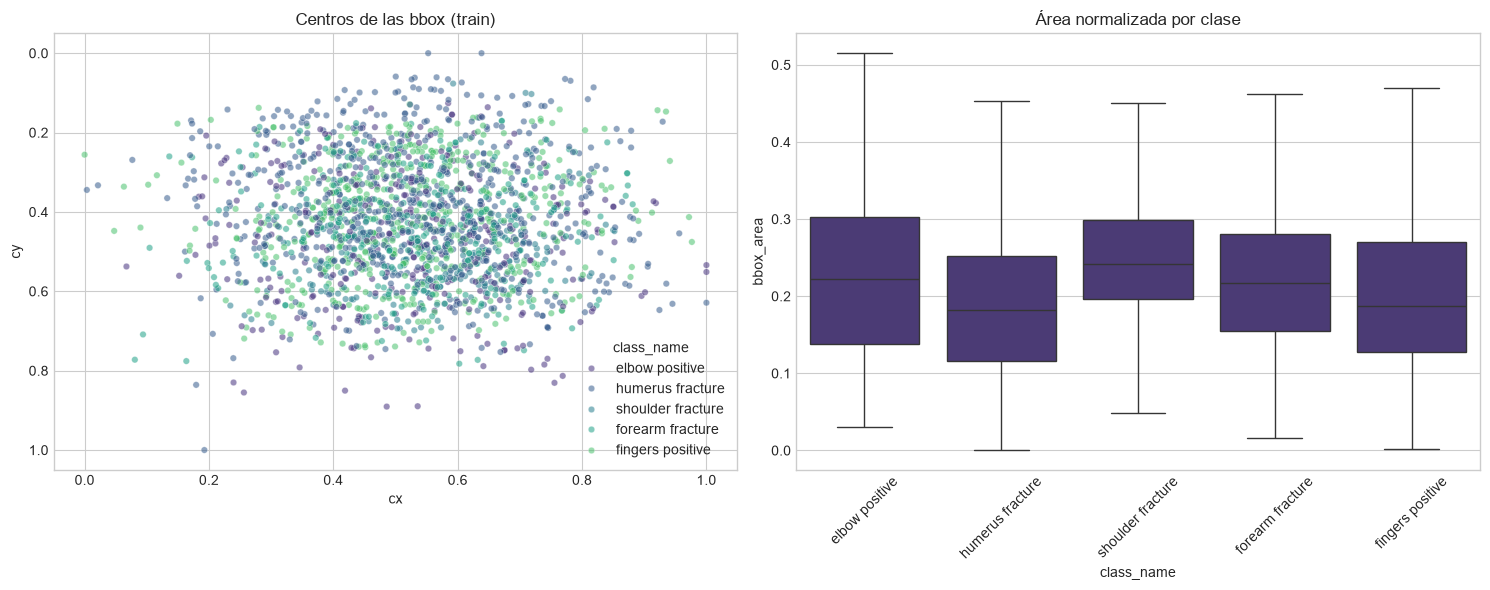

,count,mean,50%,min,max
class_name,,,,,
elbow positive,339.0,0.2307,0.2221,0.0309,0.5737
fingers positive,531.0,0.2064,0.1878,0.0024,0.5411
forearm fracture,316.0,0.2228,0.2175,0.0162,0.5357
humerus fracture,674.0,0.1966,0.1816,0.0005,0.6221
shoulder fracture,228.0,0.2527,0.2422,0.0417,0.5567


In [19]:
train_boxes = dfs['train'].copy(); train_boxes['bbox_area'] = train_boxes['bbox_w'] * train_boxes['bbox_h']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=train_boxes, x='cx', y='cy', hue='class_name', alpha=.55, s=22, ax=axes[0]); axes[0].invert_yaxis(); axes[0].set_title('Centros de las bbox (train)')
sns.boxplot(data=train_boxes, x='class_name', y='bbox_area', ax=axes[1], showfliers=False); axes[1].set_title('Área normalizada por clase'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(str(RESULTS_DIR / '01_bbox_position_area_by_class.png'), dpi=150, bbox_inches='tight'); plt.show()
display(train_boxes.groupby('class_name')['bbox_area'].describe()[['count', 'mean', '50%', 'min', 'max']].round(4))

### 6. Relación de Aspecto (Aspect Ratio) de Cajas y Multiplicidad de Fracturas

Finalmente, exploramos dos nuevas variables estadísticas intrínsecas a las cajas:
- El **Aspect Ratio (Ancho / Alto)**: Nos dice si las estructuras dañadas tienden a ser cuadradas, horizontales o verticales.
- **Anotaciones por Imagen**: Qué porcentaje de imágenes lesionadas ostenta 1, 2, 3 o múltiples fracturas en una misma radiografía.

C:\Users\lbritez\AppData\Local\Temp\ipykernel_40580\4088893377.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=boxes_per_img, palette='viridis', ax=axes[1])


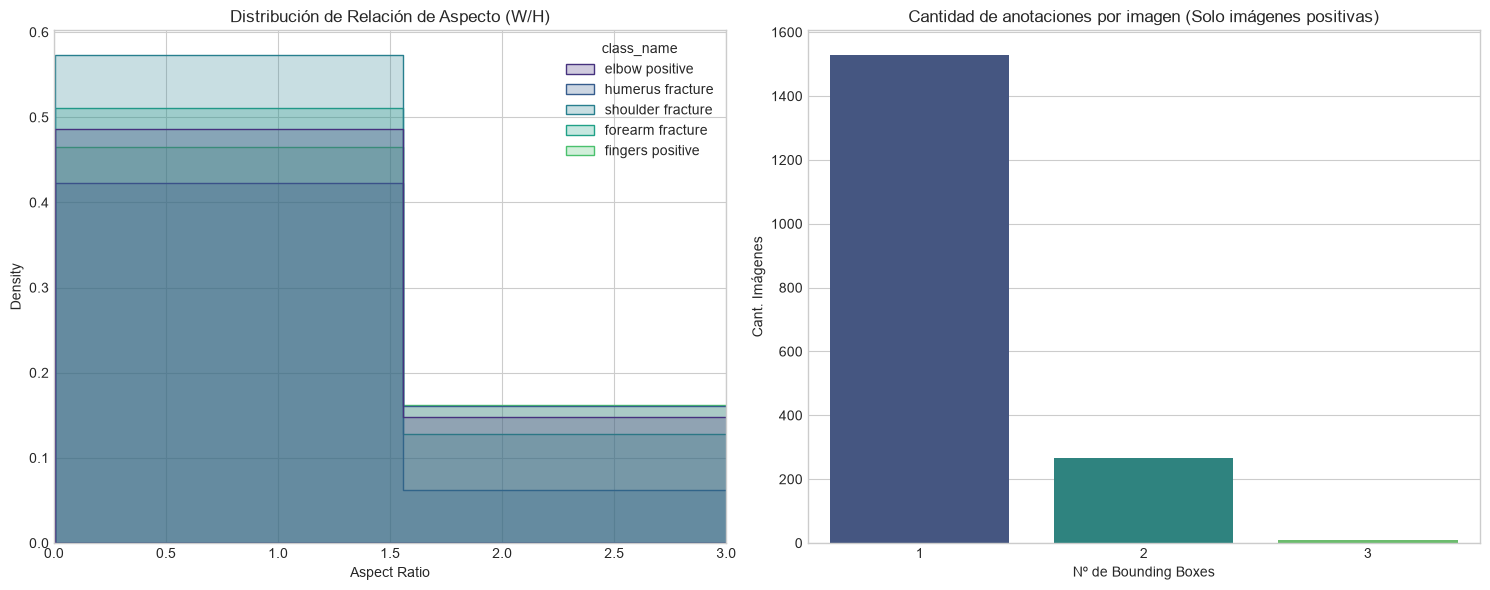

In [20]:
# Analizar Aspect Ratio
train_boxes['aspect_ratio'] = train_boxes['bbox_w'] / train_boxes['bbox_h']

# Analizar conteo de bounding boxes por imagen en las positivas
boxes_per_img = train_boxes.groupby('image').size()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(data=train_boxes, x='aspect_ratio', hue='class_name', element='step', 
             stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Distribución de Relación de Aspecto (W/H)')
axes[0].set_xlabel('Aspect Ratio')
axes[0].set_xlim(0, 3) # Acotar la cola hiperbólica si existe

sns.countplot(x=boxes_per_img, palette='viridis', ax=axes[1])
axes[1].set_title('Cantidad de anotaciones por imagen (Solo imágenes positivas)')
axes[1].set_xlabel('Nº de Bounding Boxes')
axes[1].set_ylabel('Cant. Imágenes')

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / '01_aspect_ratio_and_multiplicity.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones del EDA

A partir del análisis realizado, se obtuvieron las siguientes observaciones:

1. El dataset está formado por 4.148 radiografías: 3.631 para entrenamiento, 348 para validación y 169 para prueba. En las tres particiones, aproximadamente la mitad de las imágenes tiene al menos una caja anotada y la otra mitad no tiene cajas. Para este trabajo, estas últimas se consideran ejemplos negativos, ya que le permiten al modelo aprender cuándo no debe detectar una fractura.

2. Se observó un desbalance moderado entre las clases. En entrenamiento, `fingers positive` es la clase con más anotaciones. Con la unificación de la anomalía aisalda original hacia `humerus fracture`, hemos garantizado que no existan clases con muestras extremas que sesguen la medición, dejando 6 perfiles definidos y útiles.

3. Las cajas delimitadoras tienen tamaños variados. La mediana del área normalizada es 0,201; por lo tanto, muchas anotaciones ocupan una parte importante de la radiografía. Sin embargo, en clases como `fingers positive` y `shoulder fracture` también aparecen cajas muy pequeñas. Adicionalmente, el análisis de *Aspect Ratios* demuestra tendencias predominantes que caracterizan las diferentes estructuras óseas.

4. Las imágenes tienen resoluciones, relaciones de aspecto y niveles de brillo bastante diferentes. Por ejemplo, el ancho varía fuertemente y el brillo medio también. Por esta razón, usar un tamaño de entrada fijo y aplicar aumentos moderados de brillo, contraste, escala y rotación parece una decisión razonable para el entrenamiento.

5. No se encontraron imágenes ilegibles ni duplicados exactos entre las particiones de entrenamiento, validación y prueba. Esto es positivo porque, al menos para duplicados idénticos, no se detectó fuga de datos entre los conjuntos.

6. La auditoría encontró cajas que superan alguno de los límites de la imagen (principalmente en entrenamiento). Esto no significa necesariamente que las anotaciones estén mal, ya que suelen corresponder a recortes en el borde de la radiografía. 

En conclusión, el dataset permite realizar el experimento propuesto con un buen grado de madurez técnica. Durante la evaluación será importante analizar las métricas por clase, además de las globales, y revisar especialmente los falsos negativos. El sistema se plantea y entrena como una herramienta de apoyo para la detección de fracturas y no como un reemplazo del diagnóstico profesional.
